# Aircraft Engine TGT Anomaly Detection

This notebook identifies aircraft engines operating at higher-than-expected Turbine Gas Temperature (TGT) during cruise phase.

Approach:
- Regression-based expected TGT modeling
- Residual analysis
- Fleet-level statistical normalization
- Persistence validation
- Operational pipeline design

# Problem Statement

An issue during engine development may cause engines to operate at higher-than-expected TGT.

Goal:
Identify engines that systematically deviate from expected thermal behavior using available cruise-phase sensor data.

## Importing Libraries 

In [181]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [182]:
# Loading Datasets
aircraft_engine_sensor_data = pd.read_csv(r"D:\DataScience_challenge_Amygda\aircraft_engine_sensor_data.csv")
parameter_dictionary = pd.read_csv(r"D:\DataScience_challenge_Amygda\parameter_dictionary.csv")

# Understanding the Data

In [183]:
pd.set_option('display.max_columns', None)
aircraft_engine_sensor_data.head()

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,TRAMTOGA,N1,N2,N3,MN,GWT,ENGPOS,AP1,AP2,FF,Unnamed: 27
0,111,21/01/2019 00:00,Aircraft 1,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,0,76.20,84.5,85.7,0.798,NaN,1,NaN,NaN,5198.0,NaN
1,112,21/01/2019 00:07,Aircraft 2,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,0,79.10,87.6,88.4,0.811,NaN,2,NaN,NaN,5558.0,NaN
2,112,21/01/2019 00:08,Aircraft 2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,0,79.18,87.7,88.4,0.810,166077.0,2,NaN,NaN,5569.0,NaN
3,113,21/01/2019 00:10,Aircraft 3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,0,75.36,85.2,85.5,0.825,NaN,2,NaN,NaN,5653.0,NaN
4,114,21/01/2019 00:10,Aircraft 3,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,0,75.39,85.3,85.9,0.825,NaN,1,NaN,NaN,5694.0,NaN


In [184]:
aircraft_engine_sensor_data.shape

(76911, 28)

In [185]:
aircraft_engine_sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76911 entries, 0 to 76910
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine no    76911 non-null  int64  
 1   datetime     76911 non-null  object 
 2   aircraft no  76911 non-null  object 
 3   EPR          76905 non-null  float64
 4   AFT          76911 non-null  float64
 5   OIP          76911 non-null  int64  
 6   OIT          76911 non-null  float64
 7   P160         76910 non-null  float64
 8   P50          76911 non-null  float64
 9   P3           76909 non-null  float64
 10  T2           76911 non-null  float64
 11  T25          76910 non-null  float64
 12  T3           76911 non-null  float64
 13  TCAF         76911 non-null  int64  
 14  TCAR         76911 non-null  int64  
 15  TGT          76911 non-null  int64  
 16  TN           76910 non-null  float64
 17  TRAMTOGA     76911 non-null  int64  
 18  N1           76907 non-null  float64
 19  N2  

In [186]:
pd.set_option('display.max_columns', None)
aircraft_engine_sensor_data.describe()

,engine no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,TRAMTOGA,N1,N2,N3,MN,GWT,ENGPOS,AP1,AP2,FF,Unnamed: 27
count,76911.000000,76905.000000,76911.000000,76911.000000,76911.000000,76910.000000,76911.000000,76909.000000,76911.000000,76910.000000,76911.000000,76911.000000,76911.000000,76911.000000,76910.000000,76911.0,76907.000000,76911.000000,76911.000000,76911.000000,14686.000000,76911.000000,0.0,0.0,76901.000000,0.0
mean,129.967833,1.406912,-1.553545,78.875128,104.200754,8.181583,7.125854,141.443791,-21.374264,180.397716,444.074044,415.915370,348.965324,613.436713,121.427448,0.0,76.909997,85.803735,86.825983,0.801842,213077.546575,1.451639,NaN,NaN,5995.733280,NaN
std,12.050546,0.074490,23.920900,5.534881,7.013151,0.892824,0.776369,13.331086,9.524421,13.950903,21.910235,22.817164,26.145835,29.919178,15.624773,0.0,2.577452,1.733458,1.615648,0.023312,72488.703688,0.497659,NaN,NaN,611.252272,NaN
min,111.000000,1.011000,-5555.000000,55.000000,81.500000,5.600000,4.800000,71.600000,-48.400000,96.000000,212.300000,279.000000,210.000000,389.000000,71.000000,0.0,51.020000,56.300000,66.600000,0.403000,119939.000000,1.000000,NaN,NaN,1455.000000,NaN
25%,118.000000,1.369000,-12.000000,75.000000,99.400000,7.550000,6.576000,132.000000,-27.900000,171.400000,430.500000,402.000000,332.000000,594.000000,111.000000,0.0,75.470000,84.800000,85.800000,0.799000,173924.000000,1.000000,NaN,NaN,5573.000000,NaN
50%,130.000000,1.426000,-1.400000,79.000000,103.700000,8.040000,7.007000,140.000000,-22.400000,181.000000,445.500000,418.000000,351.000000,616.000000,120.000000,0.0,77.270000,85.900000,86.900000,0.808000,188809.000000,1.000000,NaN,NaN,5944.000000,NaN
75%,141.000000,1.458000,9.000000,82.000000,108.900000,8.650000,7.539000,149.900000,-16.000000,190.000000,458.900000,432.000000,367.000000,635.000000,131.000000,0.0,78.690000,87.000000,87.900000,0.814000,207121.000000,2.000000,NaN,NaN,6385.000000,NaN
max,150.000000,1.678000,34.500000,104.000000,129.500000,15.570000,13.868000,259.100000,16.200000,242.200000,543.500000,495.000000,495.000000,740.000000,188.000000,0.0,89.570000,94.300000,94.100000,0.846000,494863.000000,2.000000,NaN,NaN,9971.000000,NaN


In [187]:
parameter_dictionary

,Parameter,Description,unit
0,EPR,Engine pressure ratio,NaN
1,AFT,Fuel Tank Temperature,DEGC
2,OIP,Oil pressure,PSI
3,OIT,Oil temperature,DEGC
4,P160,Bypass duct total pressure,PSI
5,P50,LPT Exit Pressure,PSI
6,P3,High Pressure compressor delivery pressure,PSI
7,T2,Inlet total temperature.,DEGC
8,T25,Intermediate Pressure compressor delivery temp...,DEGC
9,T3,High Pressure compressor delivery temperature,DEGC


In [188]:
aircraft_engine_sensor_data["engine no"].unique()

array([111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
       137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
       150], dtype=int64)

In [189]:
print("Total number of Engines:", len(aircraft_engine_sensor_data["engine no"].unique()))

Total number of Engines: 40


### The dataset contains time-series cruise-phase sensor readings.Total engines: 40.Total observations: ~76k.

# Data Cleaning and Preprocessing

### Dropping 'AP1', 'AP2', 'Unnamed: 27','TRAMTOGA' columns as they contain no information at all

In [190]:
aircraft_engine_sensor_data_1 = aircraft_engine_sensor_data.drop(columns=['AP1', 'AP2', 'Unnamed: 27','TRAMTOGA'])

In [191]:
aircraft_engine_sensor_data_1.columns

Index(['engine no', 'datetime', 'aircraft no', 'EPR', 'AFT', 'OIP', 'OIT',
       'P160', 'P50', 'P3', 'T2', 'T25', 'T3', 'TCAF', 'TCAR', 'TGT', 'TN',
       'N1', 'N2', 'N3', 'MN', 'GWT', 'ENGPOS', 'FF'],
      dtype='object')

### investigating GWT column which has 81 percent of missing values

In [192]:
pd.set_option('display.max_rows', None)
aircraft_engine_sensor_data_1["GWT"].describe()

count     14686.000000
mean     213077.546575
std       72488.703688
min      119939.000000
25%      173924.000000
50%      188809.000000
75%      207121.000000
max      494863.000000
Name: GWT, dtype: float64

In [193]:
aircraft_engine_sensor_data_1["GWT"].isnull().sum()

62225

In [194]:
aircraft_engine_sensor_data_1["GWT_missing"] = aircraft_engine_sensor_data_1["GWT"].isnull().astype(int)

In [195]:
aircraft_engine_sensor_data_1.groupby("engine no")["GWT_missing"].mean()

engine no
111    0.575889
112    0.589382
113    1.000000
114    1.000000
115    0.264135
116    0.726900
117    0.726155
118    0.733854
119    0.732979
120    0.268401
121    1.000000
122    1.000000
123    0.575878
124    1.000000
125    1.000000
126    1.000000
127    1.000000
128    1.000000
129    1.000000
130    1.000000
131    0.874601
132    1.000000
133    1.000000
134    1.000000
135    1.000000
136    1.000000
137    1.000000
138    1.000000
139    1.000000
140    1.000000
141    1.000000
142    0.588999
143    0.721917
144    0.722593
145    1.000000
146    1.000000
147    0.396313
148    0.395607
149    1.000000
150    1.000000
Name: GWT_missing, dtype: float64

In [196]:
aircraft_engine_sensor_data_1.head()

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,GWT,ENGPOS,FF,GWT_missing
0,111,21/01/2019 00:00,Aircraft 1,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,76.20,84.5,85.7,0.798,NaN,1,5198.0,1
1,112,21/01/2019 00:07,Aircraft 2,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,79.10,87.6,88.4,0.811,NaN,2,5558.0,1
2,112,21/01/2019 00:08,Aircraft 2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,79.18,87.7,88.4,0.810,166077.0,2,5569.0,0
3,113,21/01/2019 00:10,Aircraft 3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,75.36,85.2,85.5,0.825,NaN,2,5653.0,1
4,114,21/01/2019 00:10,Aircraft 3,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,75.39,85.3,85.9,0.825,NaN,1,5694.0,1


In [197]:
aircraft_engine_sensor_data_1.groupby("GWT_missing")["TGT"].mean()

GWT_missing
0    618.234032
1    612.304476
Name: TGT, dtype: float64

### investigated GWT missingness and found it was structured at engine level but showed only marginal association with TGT. Given the high missing percentage (~81%) and risk of introducing spurious patterns, Iam excluding GWT to maintain model stability and avoid leakage.

In [198]:
aircraft_engine_sensor_data_2 = aircraft_engine_sensor_data_1.drop(columns=['GWT','GWT_missing'])

In [199]:
aircraft_engine_sensor_data_2.columns

Index(['engine no', 'datetime', 'aircraft no', 'EPR', 'AFT', 'OIP', 'OIT',
       'P160', 'P50', 'P3', 'T2', 'T25', 'T3', 'TCAF', 'TCAR', 'TGT', 'TN',
       'N1', 'N2', 'N3', 'MN', 'ENGPOS', 'FF'],
      dtype='object')

In [200]:
aircraft_engine_sensor_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76911 entries, 0 to 76910
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine no    76911 non-null  int64  
 1   datetime     76911 non-null  object 
 2   aircraft no  76911 non-null  object 
 3   EPR          76905 non-null  float64
 4   AFT          76911 non-null  float64
 5   OIP          76911 non-null  int64  
 6   OIT          76911 non-null  float64
 7   P160         76910 non-null  float64
 8   P50          76911 non-null  float64
 9   P3           76909 non-null  float64
 10  T2           76911 non-null  float64
 11  T25          76910 non-null  float64
 12  T3           76911 non-null  float64
 13  TCAF         76911 non-null  int64  
 14  TCAR         76911 non-null  int64  
 15  TGT          76911 non-null  int64  
 16  TN           76910 non-null  float64
 17  N1           76907 non-null  float64
 18  N2           76911 non-null  float64
 19  N3  

### Converting the 'datetime' column to actual datetime objects

In [201]:
aircraft_engine_sensor_data_2['datetime'] = pd.to_datetime(aircraft_engine_sensor_data_2['datetime'])

In [202]:
print(aircraft_engine_sensor_data_2['datetime'].dtype)

datetime64[ns]


In [203]:
aircraft_engine_sensor_data_2.isnull().sum()

engine no       0
datetime        0
aircraft no     0
EPR             6
AFT             0
OIP             0
OIT             0
P160            1
P50             0
P3              2
T2              0
T25             1
T3              0
TCAF            0
TCAR            0
TGT             0
TN              1
N1              4
N2              0
N3              0
MN              0
ENGPOS          0
FF             10
dtype: int64

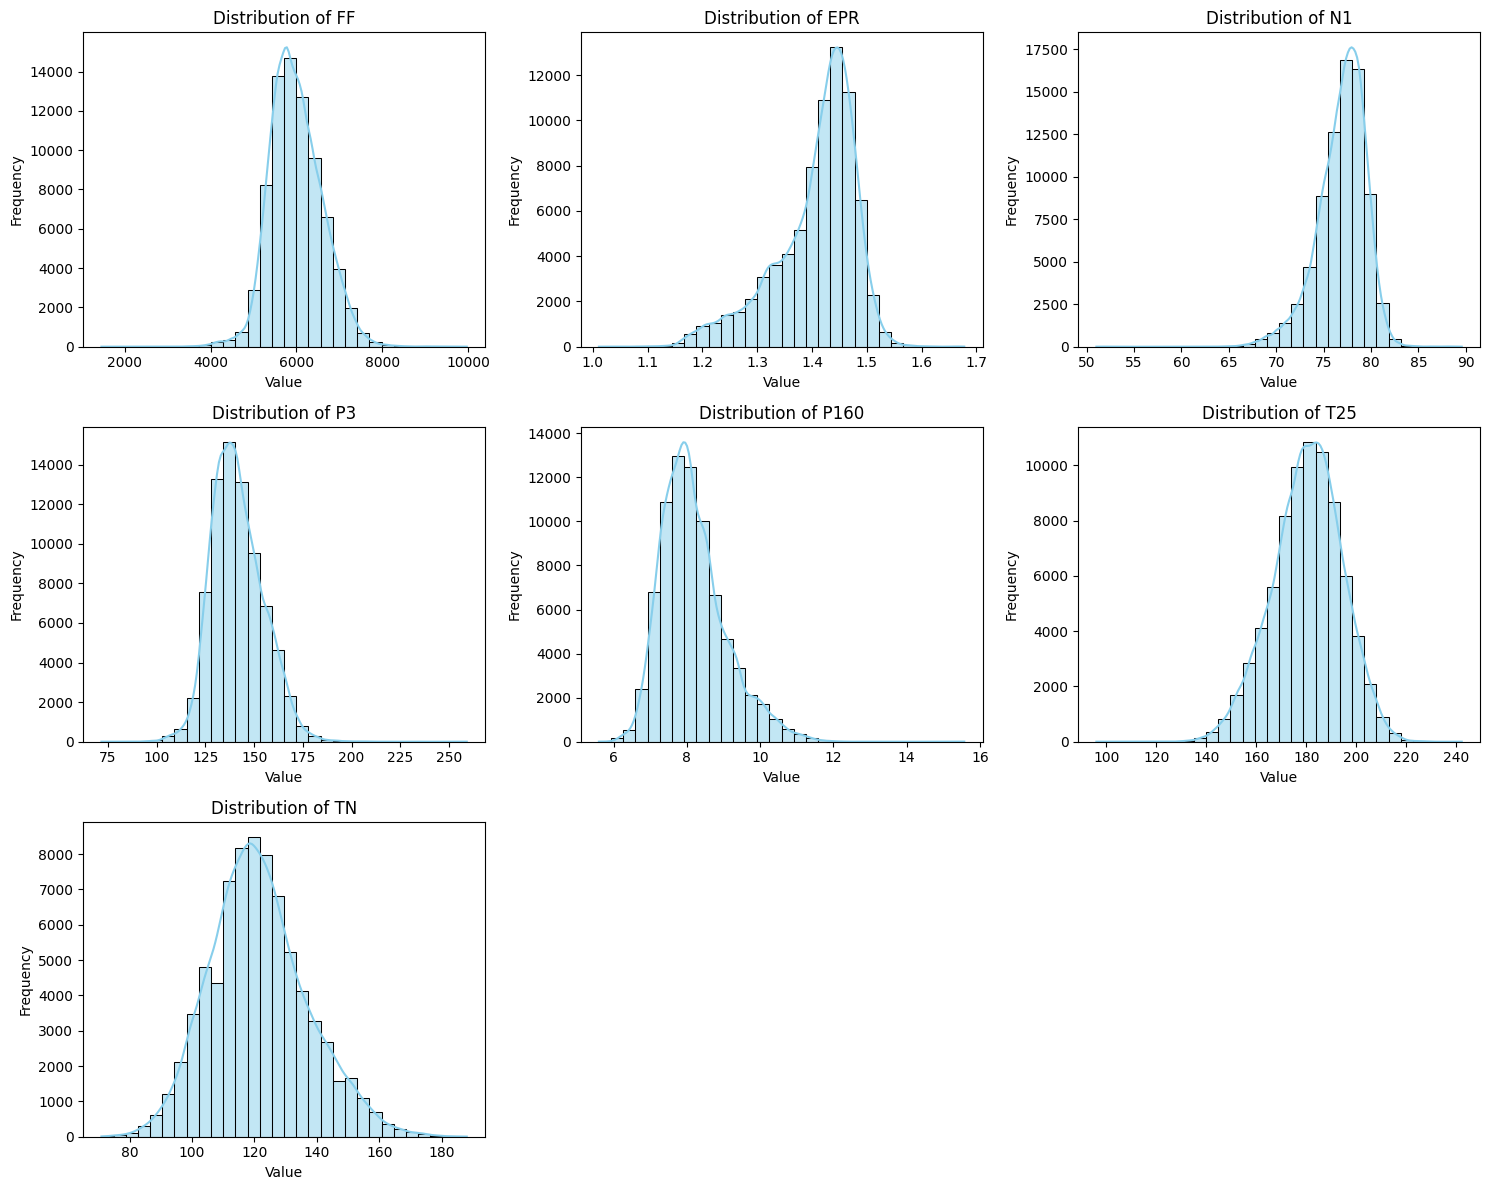

In [204]:
# List of columns that have missing values
missing_cols = ['FF', 'EPR', 'N1', 'P3', 'P160', 'T25', 'TN']

# Plot histograms
plt.figure(figsize=(15, 12))
for i, col in enumerate(missing_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(aircraft_engine_sensor_data_2[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Since the rows are very tiny which is almost 0.02 percent of the dataset size,we can ignore these rows.As imputing with any mean or median values will just make this more preprocessing complexity and we will be getting no meaningfull gain.

In [205]:
aircraft_engine_sensor_data_2.dropna(inplace=True)

In [206]:
aircraft_engine_sensor_data_2.isnull().sum()

engine no      0
datetime       0
aircraft no    0
EPR            0
AFT            0
OIP            0
OIT            0
P160           0
P50            0
P3             0
T2             0
T25            0
T3             0
TCAF           0
TCAR           0
TGT            0
TN             0
N1             0
N2             0
N3             0
MN             0
ENGPOS         0
FF             0
dtype: int64

In [207]:
aircraft_engine_sensor_data_2.describe()

,engine no,datetime,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
count,76894.000000,76894,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000,76894.000000
mean,129.967254,2019-08-03 00:17:31.519234304,1.406889,-1.556515,78.876661,104.199615,8.180875,7.125190,141.434540,-21.377673,180.398380,444.078658,415.919500,348.968437,613.439878,121.428707,76.909333,85.804509,86.826520,0.801871,1.451635,5996.019780
min,111.000000,2019-01-21 00:00:00,1.011000,-5555.000000,60.000000,81.500000,5.600000,4.800000,78.900000,-48.400000,108.200000,327.700000,279.000000,210.000000,453.000000,71.000000,51.020000,73.500000,77.100000,0.419000,1.000000,3086.000000
25%,118.000000,2019-05-12 05:50:15,1.369000,-12.000000,75.000000,99.400000,7.550000,6.576000,132.000000,-27.900000,171.400000,430.500000,402.000000,332.000000,594.000000,111.000000,75.470000,84.800000,85.800000,0.799000,1.000000,5573.000000
50%,130.000000,2019-08-07 23:31:30,1.426000,-1.400000,79.000000,103.700000,8.040000,7.006000,140.000000,-22.400000,181.000000,445.400000,418.000000,351.000000,616.000000,120.000000,77.270000,85.900000,86.900000,0.808000,1.000000,5944.000000
75%,141.000000,2019-10-29 00:08:15,1.458000,9.000000,82.000000,108.900000,8.650000,7.538000,149.900000,-16.000000,189.900000,458.900000,432.000000,367.000000,635.000000,131.000000,78.690000,87.000000,87.900000,0.814000,2.000000,6385.000000
max,150.000000,2020-01-19 23:53:00,1.678000,34.500000,104.000000,129.500000,15.570000,13.868000,219.100000,16.200000,229.800000,535.800000,495.000000,495.000000,740.000000,188.000000,89.570000,93.800000,94.100000,0.846000,2.000000,9971.000000
std,12.050338,NaN,0.074469,23.922171,5.533366,7.011861,0.891062,0.774578,13.277543,9.521247,13.929336,21.824457,22.801249,26.131916,29.850644,15.623755,2.572201,1.718779,1.607407,0.023122,0.497659,610.344706


### Investigating extreme values.

In [208]:
aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["AFT"] < -40]

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
68135,118,2019-12-13 03:55:00,Aircraft 6,1.48,-5555.0,77,107.4,11.33,9.961,204.5,-9.7,209.6,491.3,417,346,665,112.0,81.3,89.8,89.5,0.809,1,8909.0


In [209]:
# Dropping this row 
aircraft_engine_sensor_data_2.drop(index=68135, inplace=True)

In [210]:
aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["AFT"] < -40]

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF


In [211]:
aircraft_engine_sensor_data_2.shape

(76893, 23)

In [212]:
aircraft_engine_sensor_data_2.describe()

,engine no,datetime,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
count,76893.000000,76893,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000,76893.000000
mean,129.967409,2019-08-03 00:15:03.029144320,1.406888,-1.484292,78.876686,104.199573,8.180834,7.125153,141.433720,-21.377825,180.398000,444.078044,415.919486,348.968476,613.439208,121.428830,76.909276,85.804457,86.826485,0.801871,1.451641,5995.981897
min,111.000000,2019-01-21 00:00:00,1.011000,-36.500000,60.000000,81.500000,5.600000,4.800000,78.900000,-48.400000,108.200000,327.700000,279.000000,210.000000,453.000000,71.000000,51.020000,73.500000,77.100000,0.419000,1.000000,3086.000000
25%,118.000000,2019-05-12 05:48:00,1.369000,-12.000000,75.000000,99.400000,7.550000,6.576000,132.000000,-27.900000,171.400000,430.500000,402.000000,332.000000,594.000000,111.000000,75.470000,84.800000,85.800000,0.799000,1.000000,5573.000000
50%,130.000000,2019-08-07 23:31:00,1.426000,-1.400000,79.000000,103.700000,8.040000,7.006000,140.000000,-22.400000,181.000000,445.400000,418.000000,351.000000,616.000000,120.000000,77.270000,85.900000,86.900000,0.808000,1.000000,5944.000000
75%,141.000000,2019-10-29 00:03:00,1.458000,9.000000,82.000000,108.900000,8.650000,7.538000,149.900000,-16.000000,189.900000,458.900000,432.000000,367.000000,635.000000,131.000000,78.690000,87.000000,87.900000,0.814000,2.000000,6385.000000
max,150.000000,2020-01-19 23:53:00,1.678000,34.500000,104.000000,129.500000,15.570000,13.868000,219.100000,16.200000,229.800000,535.800000,495.000000,495.000000,740.000000,188.000000,89.570000,93.800000,94.100000,0.846000,2.000000,9971.000000
std,12.050339,NaN,0.074469,13.083612,5.533397,7.011897,0.890995,0.774515,13.275681,9.521216,13.929029,21.823935,22.801397,26.132083,29.850259,15.623819,2.572169,1.718730,1.607389,0.023122,0.497659,610.258263


In [213]:
aircraft_engine_sensor_data_2.head()

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
0,111,2019-01-21 00:00:00,Aircraft 1,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,76.20,84.5,85.7,0.798,1,5198.0
1,112,2019-01-21 00:07:00,Aircraft 2,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,79.10,87.6,88.4,0.811,2,5558.0
2,112,2019-01-21 00:08:00,Aircraft 2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,79.18,87.7,88.4,0.810,2,5569.0
3,113,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,75.36,85.2,85.5,0.825,2,5653.0
4,114,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,75.39,85.3,85.9,0.825,1,5694.0


### We have verified every features about the extreme values

# Exploratory Data Analysis

## TGT Distribution

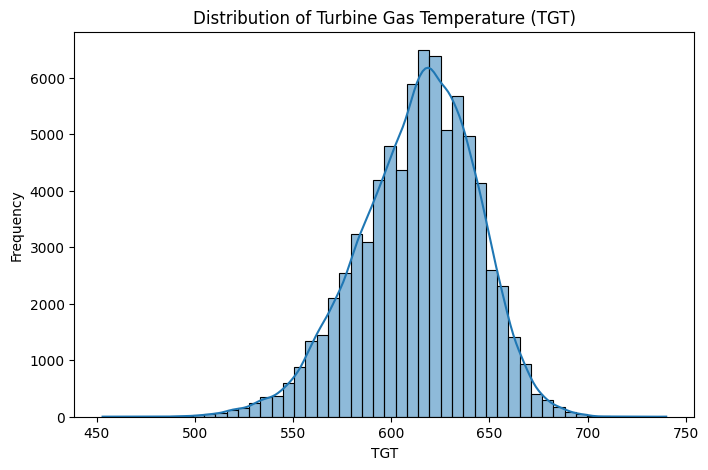

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(aircraft_engine_sensor_data_2["TGT"], bins=50, kde=True)
plt.title("Distribution of Turbine Gas Temperature (TGT)")
plt.xlabel("TGT")
plt.ylabel("Frequency")

plt.savefig("D:\Amygda_project\plots\tgt_distribution.png")
plt.show()

### TGT Distribution Insight

The Turbine Gas Temperature (TGT) follows an approximately normal distribution centered around ~610–620°C, with no clear bimodal separation or extreme clustering.

This indicates:
- No obvious threshold-based separation of faulty engines.
- Most engines operate within a common thermal range.
- A regression-based expected-value modeling approach is appropriate.

### Grouping TGT with respect to engines to analyze the behaviour

In [215]:
aircraft_engine_sensor_data_2.groupby("engine no")["TGT"].agg(["mean", "std", "count"]).sort_values("mean")

,mean,std,count
engine no,,,
113,588.074391,23.638433,3038
114,589.148404,23.978266,3039
126,592.428105,22.988897,918
119,594.593894,30.337375,2817
123,597.397508,28.249986,1766
130,599.053543,28.102758,1905
144,599.848211,26.853563,2543
132,600.610039,29.749904,2849
143,600.708333,26.984154,2544


#### Here only with this high average TGT information we cant conclude that the higher TGT engines are abnormal.There might be influence of other parameters too.So raw TGT is not enough here.
#### We must answer are those high mean engines running hot because of conditions (or) Because they are abnormal?

### Correlation with TGT

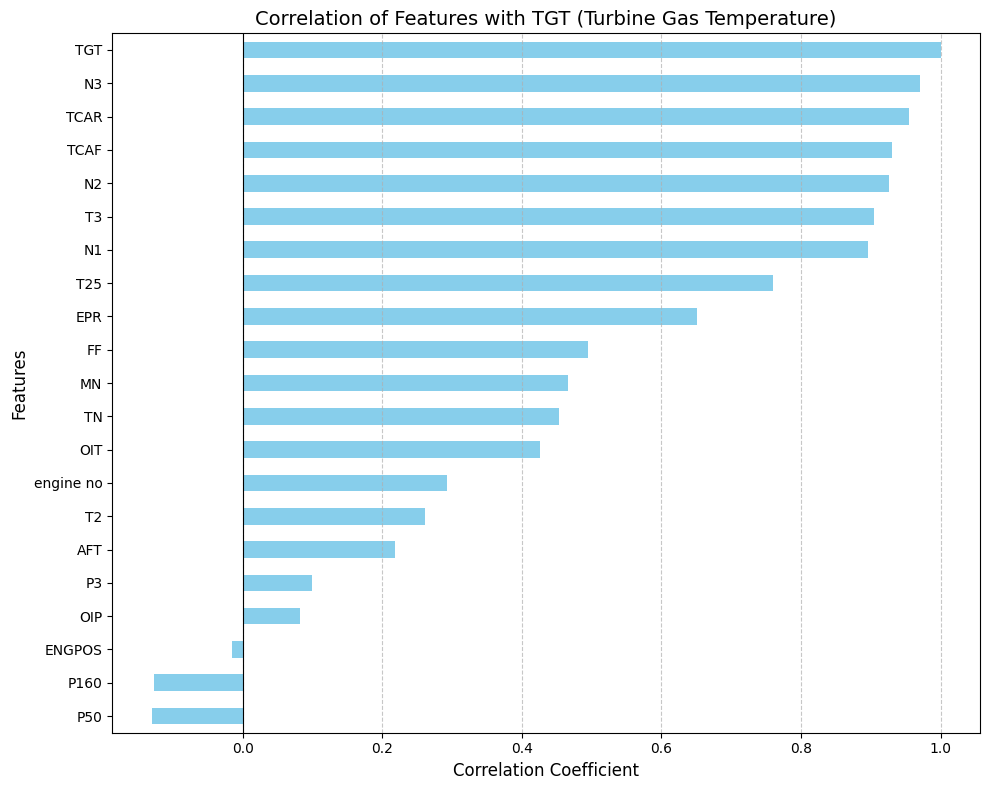

In [ ]:
numeric_df = aircraft_engine_sensor_data_2.select_dtypes(include=['int64','float64'])


# Sorting in ascending=True helps keep the highest correlation at the top in a horizontal bar chart
correlations = numeric_df.corr()["TGT"].sort_values(ascending=True)

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='skyblue')

# Customizing the chart
plt.title('Correlation of Features with TGT (Turbine Gas Temperature)', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(0, color='black', linewidth=0.8) # Reference line at 0

plt.tight_layout()
plt.savefig("D:\Amygda_project\plots\tgt_correlation.png")

In [217]:
corr = numeric_df.corr()["TGT"].sort_values(ascending=False)
print(corr)

TGT          1.000000
N3           0.971158
TCAR         0.954069
TCAF         0.930983
N2           0.925430
T3           0.904771
N1           0.896092
T25          0.760586
EPR          0.651141
FF           0.495284
MN           0.466578
TN           0.453650
OIT          0.426278
engine no    0.292919
T2           0.261425
AFT          0.218045
P3           0.099381
OIP          0.081816
ENGPOS      -0.015751
P160        -0.126456
P50         -0.130602
Name: TGT, dtype: float64


### Correlation Analysis Insight

TGT shows very strong positive correlation with rotational speed (N3, N2), compressor temperatures (T3, T25), and pressure-related variables (TCAR, TCAF).

This confirms:
- TGT is strongly influenced by operating conditions.
- Higher engine load naturally leads to higher TGT.
- Raw TGT values alone cannot identify anomalies without contextual modeling.

## TGT vs Key Feature Scatter

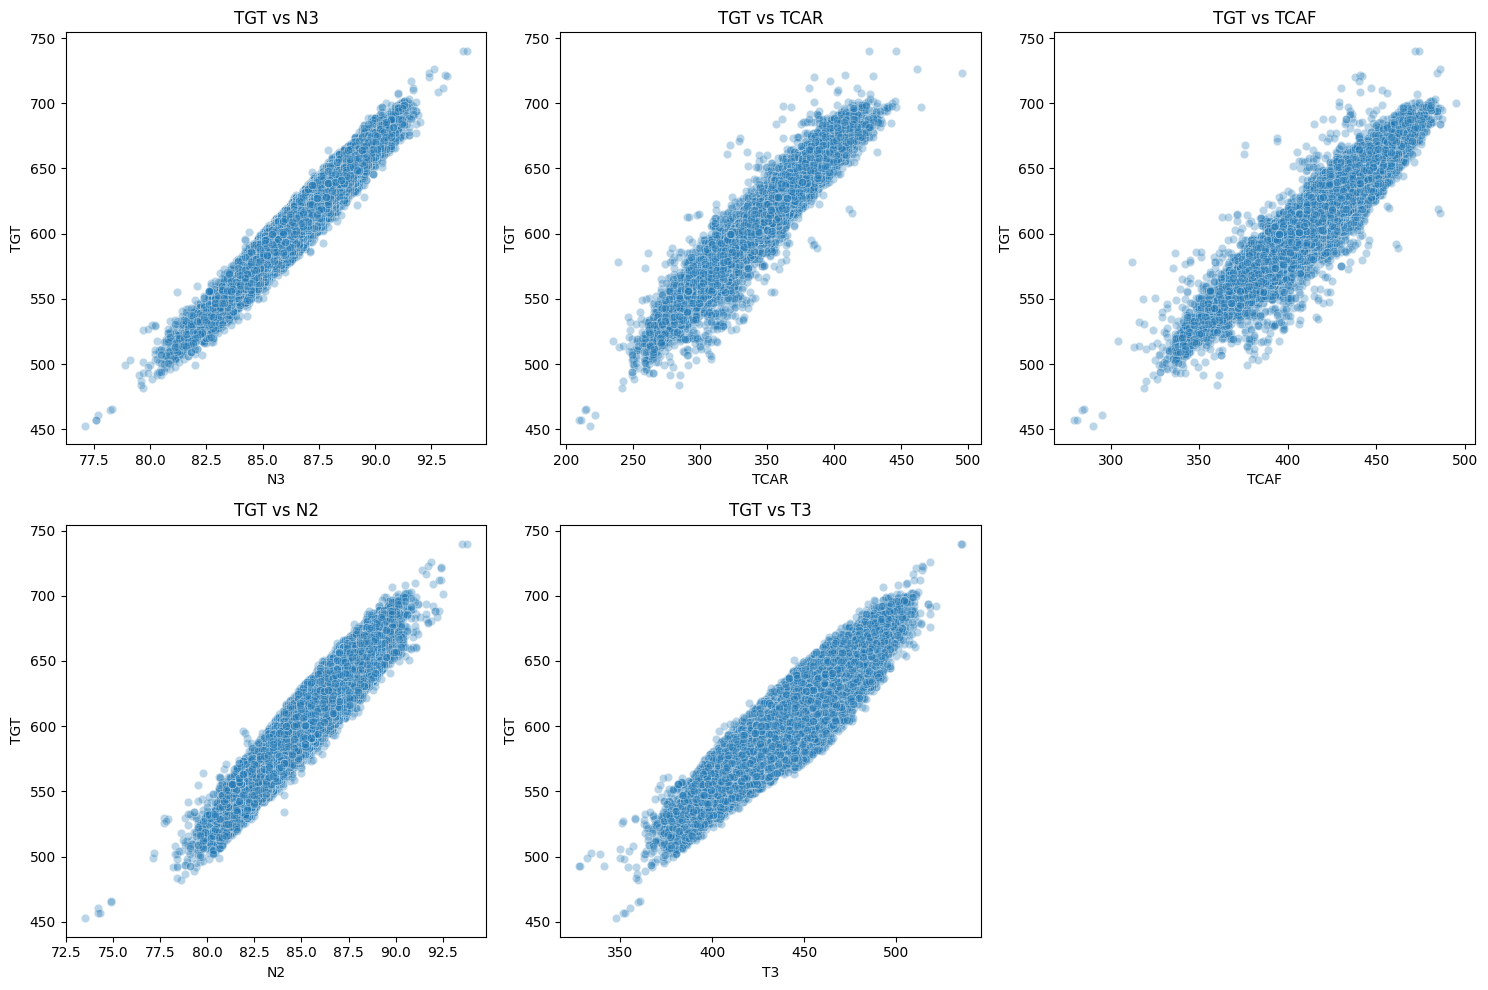

In [ ]:
# Set the overall figure size for a 2-row layout
plt.figure(figsize=(15, 10))

# Plot 1
plt.subplot(2, 3, 1)
sns.scatterplot(x="N3", y="TGT", data=aircraft_engine_sensor_data_2, alpha=0.3)
plt.title("TGT vs N3")

# Plot 2
plt.subplot(2, 3, 2)
sns.scatterplot(x="TCAR", y="TGT", data=aircraft_engine_sensor_data_2, alpha=0.3)
plt.title("TGT vs TCAR")

# Plot 3
plt.subplot(2, 3, 3)
sns.scatterplot(x="TCAF", y="TGT", data=aircraft_engine_sensor_data_2, alpha=0.3)
plt.title("TGT vs TCAF")

# Plot 4
plt.subplot(2, 3, 4)
sns.scatterplot(x="N2", y="TGT", data=aircraft_engine_sensor_data_2, alpha=0.3)
plt.title("TGT vs N2")

# Plot 5
plt.subplot(2, 3, 5)
sns.scatterplot(x="T3", y="TGT", data=aircraft_engine_sensor_data_2, alpha=0.3)
plt.title("TGT vs T3")

# Automatically adjust spacing so titles don't overlap axes
plt.tight_layout()
plt.savefig("D:\Amygda_project\plots\tgt_vs_keyfeatures.png")
plt.show()

### Operating Condition Relationships

The scatter plots show strong linear relationships between TGT and key operational parameters such as N3, N2, T3, TCAR, and TCAF.

Observations:
- TGT increases consistently with compressor speed and temperature.
- The relationships appear stable and predictable.
- This validates the use of multivariate regression to model expected TGT.

Therefore, deviations from this learned relationship (residuals) can be interpreted as abnormal thermal behavior.

## Engine-Level Raw TGT Comparison

In [219]:
engine_tgt_mean = aircraft_engine_sensor_data_2.groupby("engine no")["TGT"].mean()

engine_tgt_mean.sort_values(ascending=False).head()

engine no
137    645.172075
131    644.507188
148    636.982908
139    635.837182
136    635.452075
Name: TGT, dtype: float64

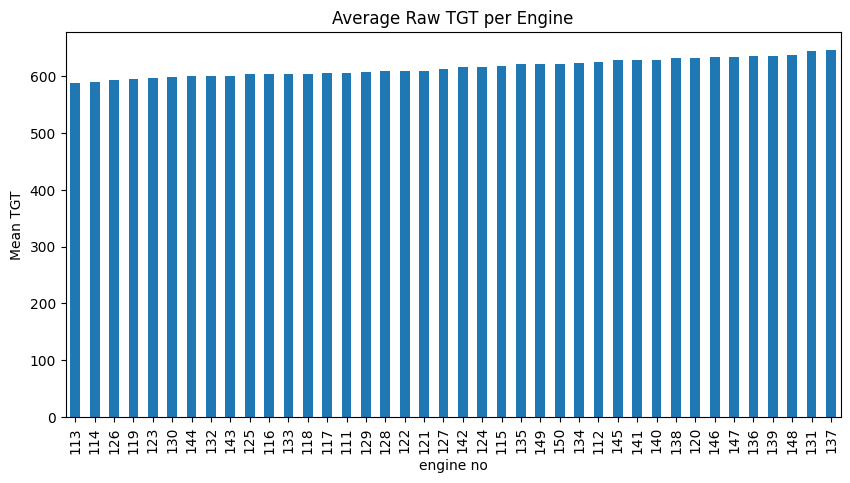

In [ ]:
plt.figure(figsize=(10,5))
engine_tgt_mean.sort_values().plot(kind="bar")
plt.title("Average Raw TGT per Engine")
plt.ylabel("Mean TGT")
plt.savefig("D:\Amygda_project\plots\avg_tgt_per_engine.png")
plt.show()

### Engine-Level Raw TGT Comparison

Some engines exhibit slightly higher average raw TGT values compared to others.

However:
- The variation across engines is relatively gradual.
- Raw averages do not account for differences in operating conditions.
- Higher raw TGT does not necessarily imply abnormal behavior.

This reinforces the need to model expected TGT first, and then analyze residual deviations instead of using raw values.

### EDA Summary

The exploratory analysis confirms that TGT is strongly dependent on engine operating conditions and exhibits predictable multivariate relationships.

Therefore, anomaly detection must be based on deviations from expected thermal behavior rather than raw temperature thresholds.

In [221]:
aircraft_engine_sensor_data_2["ENGPOS"].describe()

count    76893.000000
mean         1.451641
std          0.497659
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: ENGPOS, dtype: float64

In [222]:
# Dropping 'ENGPOS' from the dataframe directly(As it might act like a proxy for engine identity)
numeric_df.drop(columns=['ENGPOS'], inplace=True)

In [223]:
aircraft_engine_sensor_data_2.head()

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
0,111,2019-01-21 00:00:00,Aircraft 1,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,76.20,84.5,85.7,0.798,1,5198.0
1,112,2019-01-21 00:07:00,Aircraft 2,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,79.10,87.6,88.4,0.811,2,5558.0
2,112,2019-01-21 00:08:00,Aircraft 2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,79.18,87.7,88.4,0.810,2,5569.0
3,113,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,75.36,85.2,85.5,0.825,2,5653.0
4,114,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,75.39,85.3,85.9,0.825,1,5694.0


In [224]:
aircraft_engine_sensor_data_2.shape

(76893, 23)

In [225]:
numeric_df.drop(columns=['engine no'], inplace=True)

In [226]:
numeric_df.head()

,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,FF
0,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,76.20,84.5,85.7,0.798,5198.0
1,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,79.10,87.6,88.4,0.811,5558.0
2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,79.18,87.7,88.4,0.810,5569.0
3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,75.36,85.2,85.5,0.825,5653.0
4,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,75.39,85.3,85.9,0.825,5694.0


In [227]:
numeric_df.shape

(76893, 19)

## Modeling Strategy

The dataset does not contain labeled anomaly indicators. Therefore, a supervised classification approach is not feasible.

Instead, we model the *expected* Turbine Gas Temperature (TGT) as a function of operating conditions using regression.  

Key idea:
- Train a regression model to predict expected TGT.
- Compute residual = Actual TGT − Predicted TGT.
- Engines with systematically positive residuals are candidates for overheating.

To prevent data leakage and ensure proper generalization, the dataset was split **engine-wise** rather than randomly.  
This ensures the model learns general thermal behavior patterns rather than memorizing individual engine characteristics.

In [228]:
unique_engines = aircraft_engine_sensor_data_2["engine no"].unique()

In [229]:
# Split engines (80/20)

train_engines, test_engines = train_test_split(
    unique_engines,
    test_size=0.2,
    random_state=42
)

print("Train engines:", len(train_engines))
print("Test engines:", len(test_engines))

Train engines: 32
Test engines: 8


### Create train and test datasets

In [230]:
train_df = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"].isin(train_engines)]
test_df  = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"].isin(test_engines)]

print("Train rows:", train_df.shape)
print("Test rows:", test_df.shape)

Train rows: (63571, 23)
Test rows: (13322, 23)


In [231]:
train_df.head()

,engine no,datetime,aircraft no,EPR,AFT,OIP,OIT,P160,P50,P3,T2,T25,T3,TCAF,TCAR,TGT,TN,N1,N2,N3,MN,ENGPOS,FF
0,111,2019-01-21 00:00:00,Aircraft 1,1.414,-11.5,71,106.3,7.11,6.181,124.2,-32.4,162.5,420.4,397,338,595,114.0,76.20,84.5,85.7,0.798,1,5198.0
1,112,2019-01-21 00:07:00,Aircraft 2,1.459,-18.8,85,106.5,7.16,6.169,127.5,-21.9,187.8,460.2,440,380,638,117.0,79.10,87.6,88.4,0.811,2,5558.0
2,112,2019-01-21 00:08:00,Aircraft 2,1.460,-18.8,86,106.3,7.16,6.173,127.6,-21.8,188.5,461.5,441,381,640,117.0,79.18,87.7,88.4,0.810,2,5569.0
3,113,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,82,101.4,8.34,7.274,140.7,-15.5,184.1,441.3,414,341,594,127.0,75.36,85.2,85.5,0.825,2,5653.0
4,114,2019-01-21 00:10:00,Aircraft 3,1.341,-5.0,78,103.9,8.30,7.288,141.5,-15.5,185.1,442.3,417,345,594,129.0,75.39,85.3,85.9,0.825,1,5694.0


In [232]:
train_df.shape

(63571, 23)

In [233]:
feature_list = [
    "EPR","AFT","OIP","OIT","P160","P50","P3",
    "T2","T25","T3","TCAF","TCAR","TN",
    "N1","N2","N3","MN","FF"
]

In [234]:
X_train = train_df[feature_list]
y_train = train_df["TGT"]

X_test  = test_df[feature_list]
y_test  = test_df["TGT"]

## Building Pipeline With Normalization and Model Training

### Model 1 — Linear Regression

In [235]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

print("Linear Train R2:", linear_pipeline.score(X_train, y_train))
print("Linear Test R2:", linear_pipeline.score(X_test, y_test))

Linear Train R2: 0.9815962694364504
Linear Test R2: 0.993537629529989


### Model 2 — Random Forest

In [236]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),  # harmless for RF
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

print("RF Train R2:", rf_pipeline.score(X_train, y_train))
print("RF Test R2:", rf_pipeline.score(X_test, y_test))

RF Train R2: 0.9979221872697059
RF Test R2: 0.97594989003759


#### Linear regression achieved strong generalization performance with minimal train-test gap, suggesting that the thermodynamic relationships are largely linear. Given the objective of building a stable fleet-wide baseline for anomaly detection, a simpler model was preferred over a more flexible model like Random Forest, which showed mild overfitting.

## Refit Linear Regression On Full Dataset

In [237]:
X_full = aircraft_engine_sensor_data_2[feature_list]
y_full = aircraft_engine_sensor_data_2["TGT"]

In [238]:
# Refitting Pipeline On Full Data
linear_pipeline.fit(X_full, y_full)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


## Computing Predictions and Residuals(Residual Analysis)

In [239]:
aircraft_engine_sensor_data_2["predicted_TGT"] = linear_pipeline.predict(X_full)

aircraft_engine_sensor_data_2["residual"] = aircraft_engine_sensor_data_2["TGT"] - aircraft_engine_sensor_data_2["predicted_TGT"]

## Inspecting Residual Distribution

In [240]:
aircraft_engine_sensor_data_2["residual"].describe()

count    7.689300e+04
mean     2.891073e-14
std      3.773954e+00
min     -4.029843e+01
25%     -2.429417e+00
50%     -6.149523e-01
75%      1.803358e+00
max      4.231591e+01
Name: residual, dtype: float64

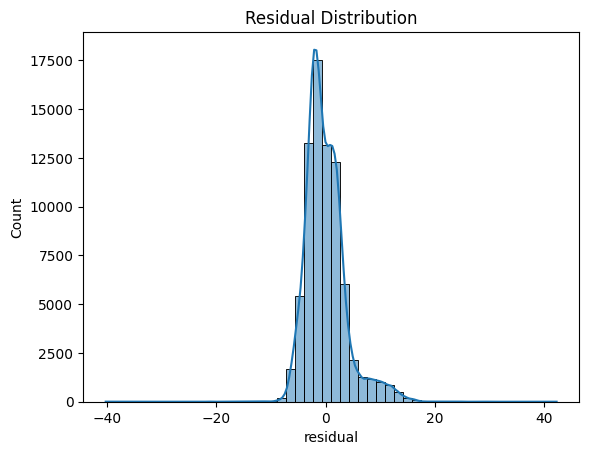

In [ ]:
sns.histplot(aircraft_engine_sensor_data_2["residual"], bins=50, kde=True)
plt.title("Residual Distribution")
plt.savefig("D:\Amygda_project\plots\residual_distribution.png")
plt.show()

Large positive residuals indicate engines operating hotter than expected under similar conditions.

Residual distribution confirms:
- Model predictions are unbiased.
- Deviations represent true behavioral shifts rather than modeling error.

### Engine-Level Aggregation

In [242]:
engine_stats = aircraft_engine_sensor_data_2.groupby("engine no")["residual"].agg([
    "mean",
    "median",
    "std",
    "count"
]).reset_index()

engine_stats

,engine no,mean,median,std,count
0,111,1.914164,1.992479,1.134485,1153
1,112,-2.892674,-2.857655,1.265309,2976
2,113,-1.580219,-1.741236,1.578785,3038
3,114,-1.085627,-1.219400,1.568624,3039
4,115,-2.922938,-2.919760,1.025892,1185
5,116,-3.725600,-3.689631,1.736882,2684
6,117,-1.552615,-1.650133,1.525764,2684
7,118,7.247929,7.210951,3.610938,2814
8,119,-4.081951,-4.441725,2.421729,2817
9,120,4.338679,4.375464,1.509221,1575


### Computing Fleet-Level Mean & Std (Engine Means)

In [243]:
fleet_mean = engine_stats["mean"].mean()
fleet_std  = engine_stats["mean"].std()

print("Fleet mean of engine means:", fleet_mean)
print("Fleet std of engine means:", fleet_std)

Fleet mean of engine means: 0.35251811094769614
Fleet std of engine means: 3.758909653549071


### Computing Z-score Per Engine

In [244]:
engine_stats["z_score"] = (
    (engine_stats["mean"] - fleet_mean) / fleet_std
)

In [245]:
engine_stats.sort_values("z_score", ascending=False)

,engine no,mean,median,std,count,z_score
38,149,11.234578,11.329554,3.240210,970,2.895004
20,131,8.322730,8.526385,3.760938,1252,2.120352
14,125,8.177976,8.317929,2.965909,918,2.081843
7,118,7.247929,7.210951,3.610938,2814,1.834418
28,139,6.462358,6.558201,3.118997,866,1.625429
9,120,4.338679,4.375464,1.509221,1575,1.060457
26,137,2.872792,2.884532,1.083061,1325,0.670480
30,141,2.568880,2.506897,1.146099,2633,0.589629
29,140,2.190344,2.168930,1.092133,2635,0.488925
22,133,2.053434,1.930720,1.162326,2849,0.452502


## Using a regression-based baseline and fleet-relative statistical analysis, engines 149, 131, and 125 were identified as statistically significant positive deviations in turbine gas temperature during cruise phase.

#### Are these engines consistently high?
#### Or is it few extreme points driving mean?

#### Lets check Persistence

Let’s define:

Row-level threshold = 2 × residual std
Residual std ≈ 3.77

So threshold ≈ 7.5°C

Now compute for each engine:

% of rows where residual > 7.5

In [246]:
threshold = 2 * aircraft_engine_sensor_data_2["residual"].std()

aircraft_engine_sensor_data_2["high_residual"] = aircraft_engine_sensor_data_2["residual"] > threshold

engine_persistence = aircraft_engine_sensor_data_2.groupby("engine no")["high_residual"].mean().reset_index()

engine_persistence.sort_values("high_residual", ascending=False)

,engine no,high_residual
38,149,0.845361
20,131,0.591853
14,125,0.583878
7,118,0.466951
28,139,0.392610
34,145,0.009326
9,120,0.006349
18,129,0.005771
8,119,0.004260
19,130,0.003675


#### Persistence measures the percentage of cruise snapshots where an engine's residual exceeds 2× the normal residual standard deviation.  
#### Engines 149, 131, and 125 show high persistence (>50%), indicating systematic overheating rather than isolated spikes.  
#### Engines 118 and 139 show elevated but less consistent deviations and are considered monitoring candidates.

## Trend Analysis using timestamps

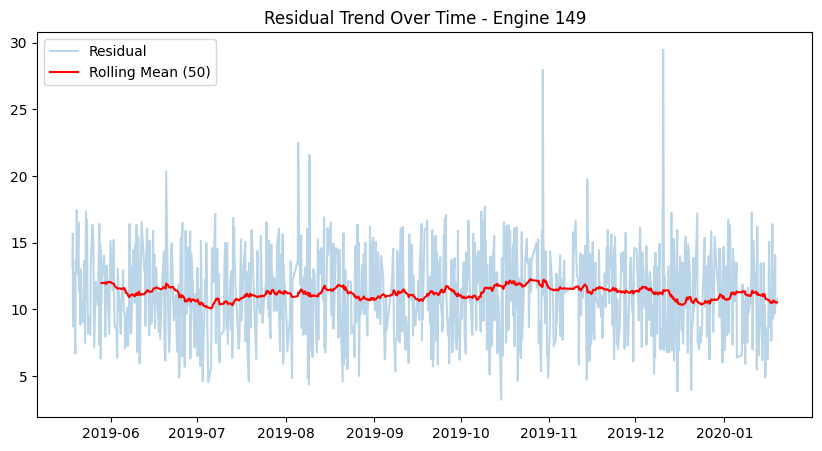

In [247]:
import matplotlib.pyplot as plt

engine_id = 149

df_engine = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"] == engine_id].sort_values("datetime")

df_engine["rolling_residual"] = df_engine["residual"].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(df_engine["datetime"], df_engine["residual"], alpha=0.3, label="Residual")
plt.plot(df_engine["datetime"], df_engine["rolling_residual"], color="red", label="Rolling Mean (50)")
plt.title(f"Residual Trend Over Time - Engine {engine_id}")
plt.legend()
plt.show()

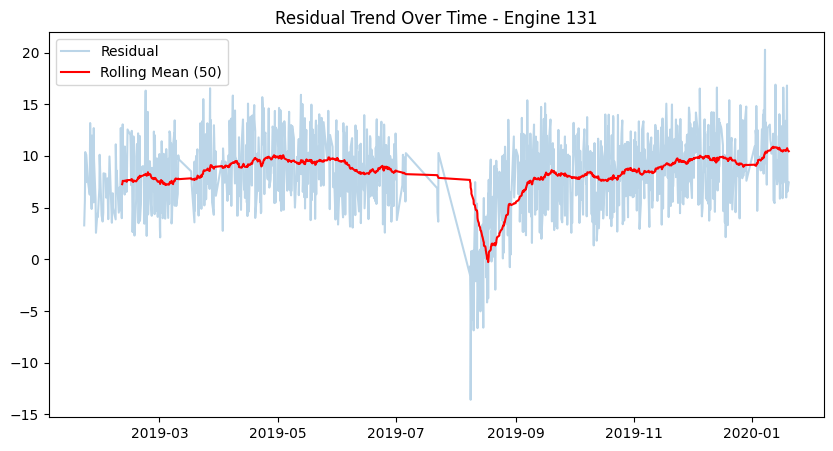

In [248]:
engine_id = 131

df_engine = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"] == engine_id].sort_values("datetime")

df_engine["rolling_residual"] = df_engine["residual"].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(df_engine["datetime"], df_engine["residual"], alpha=0.3, label="Residual")
plt.plot(df_engine["datetime"], df_engine["rolling_residual"], color="red", label="Rolling Mean (50)")
plt.title(f"Residual Trend Over Time - Engine {engine_id}")
plt.legend()
plt.show()

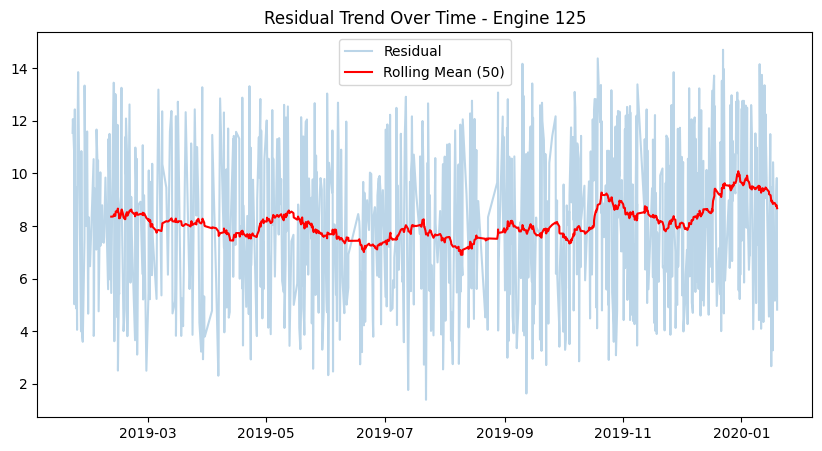

In [249]:
engine_id = 125

df_engine = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"] == engine_id].sort_values("datetime")

df_engine["rolling_residual"] = df_engine["residual"].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(df_engine["datetime"], df_engine["residual"], alpha=0.3, label="Residual")
plt.plot(df_engine["datetime"], df_engine["rolling_residual"], color="red", label="Rolling Mean (50)")
plt.title(f"Residual Trend Over Time - Engine {engine_id}")
plt.legend()
plt.show()

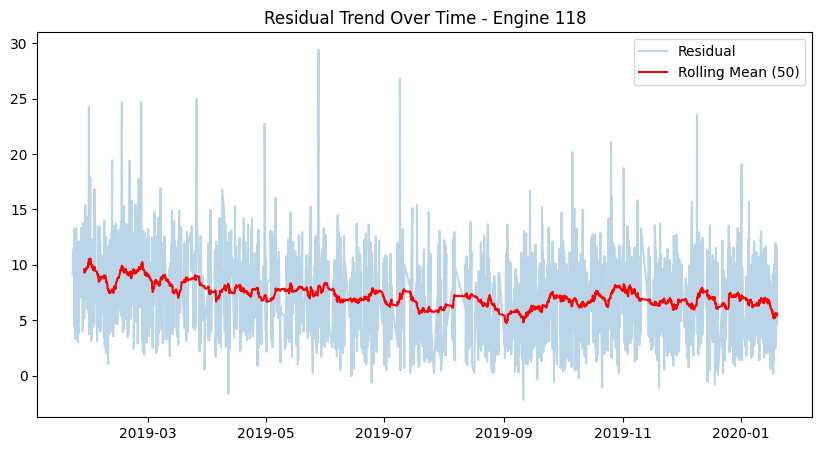

In [250]:
engine_id = 118

df_engine = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"] == engine_id].sort_values("datetime")

df_engine["rolling_residual"] = df_engine["residual"].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(df_engine["datetime"], df_engine["residual"], alpha=0.3, label="Residual")
plt.plot(df_engine["datetime"], df_engine["rolling_residual"], color="red", label="Rolling Mean (50)")
plt.title(f"Residual Trend Over Time - Engine {engine_id}")
plt.legend()
plt.show()

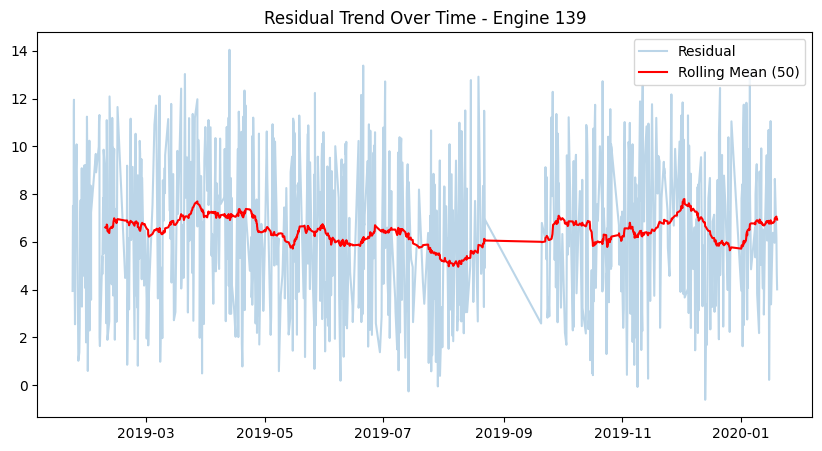

In [251]:
engine_id = 139

df_engine = aircraft_engine_sensor_data_2[aircraft_engine_sensor_data_2["engine no"] == engine_id].sort_values("datetime")

df_engine["rolling_residual"] = df_engine["residual"].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(df_engine["datetime"], df_engine["residual"], alpha=0.3, label="Residual")
plt.plot(df_engine["datetime"], df_engine["rolling_residual"], color="red", label="Rolling Mean (50)")
plt.title(f"Residual Trend Over Time - Engine {engine_id}")
plt.legend()
plt.show()

### Temporal trend analysis confirms that engines 149, 131, and 125 exhibit consistently elevated residuals over time, indicating systematic overheating rather than isolated spikes.

## Saving the model

In [252]:
import joblib
from pathlib import Path
joblib.dump(linear_pipeline, "tgt_regression_pipeline.joblib")

save_dir = Path(r"D:\Amygda_project\model")

save_path = save_dir / "tgt_regression_pipeline.joblib"

# 4. Save the model
joblib.dump(linear_pipeline, save_path)

print(f"Model saved successfully at: {save_path}")

Model saved successfully at: D:\Amygda_project\model\tgt_regression_pipeline.joblib


## Saving cleaned data

In [253]:
import os

FEATURE_LIST = [
    "EPR","AFT","OIP","OIT","P160","P50","P3",
    "T2","T25","T3","TCAF","TCAR","TN",
    "N1","N2","N3","MN","FF"
]
clean_columns = FEATURE_LIST + ["engine no", "datetime", "TGT","aircraft no"]
df_base = aircraft_engine_sensor_data_2[clean_columns].copy()
folder_path = r'D:\Amygda_project\CleanedData'



file_name = 'cleaned_aircraft_sensor_data.csv'
full_path = os.path.join(folder_path, file_name)

# 4. Save the DataFrame
df_base.to_csv(full_path, index=False)

print(f"Data successfully saved to: {full_path}")

Data successfully saved to: D:\Amygda_project\CleanedData\cleaned_aircraft_sensor_data.csv


In [254]:
!python pipeline_script.py

2026-03-01 19:40:02,545 - INFO - ===== TGT Anomaly Detection Pipeline Started =====
2026-03-01 19:40:02,545 - INFO - Loading trained regression pipeline...
2026-03-01 19:40:05,535 - INFO - Model loaded successfully.
2026-03-01 19:40:05,536 - INFO - Loading cleaned dataset...
2026-03-01 19:40:06,915 - INFO - Data saved to SQLite database.
2026-03-01 19:40:08,470 - INFO - Data loaded from SQLite successfully.
2026-03-01 19:40:08,473 - INFO - Validating input dataset...
2026-03-01 19:40:08,506 - INFO - Data validation completed successfully.
2026-03-01 19:40:08,507 - INFO - Running TGT predictions...
2026-03-01 19:40:08,551 - INFO - Prediction completed.
2026-03-01 19:40:08,552 - INFO - Computing residuals...
2026-03-01 19:40:08,555 - INFO - Residual computation completed.
2026-03-01 19:40:08,555 - INFO - Computing engine-level statistics...
2026-03-01 19:40:08,589 - INFO - Engine-level anomaly statistics computed.
2026-03-01 19:40:08,589 - INFO - Identifying affected engines...
2026-03-0